In [14]:
%matplotlib inline 
import torch
from d2l import torch as d2l

# Define model 

In [15]:
class LinearRegressionScratch(d2l.Module): #@save 
    """The Linear regression model implemented from scratch"""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(mean=0, std=sigma, size=(num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [16]:
# forward method
@d2l.add_to_class(LinearRegressionScratch) #@save 
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [17]:
# loss function 
@d2l.add_to_class(LinearRegressionScratch) #@save 
def loss(self, y_hat, y):
    l = (y_hat - y)**2 / 2
    return l.mean()

In [18]:
# defining the optimization algorithm 
class SGD(d2l.HyperParameters): #@save
    """Minibatch stochastic gradient descent"""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad
    
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [19]:
# add instance sgd to linear regression class 
@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

- traininng algo

- init parameters
- repeat until done
    - compute gradient
    - update parameters



In [ ]:
@d2l.add_to_class(d2l.Trainer) #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer) #@save
def fit_epoch(self):
    self.model.train() # switch to train mode
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch)) # forward and return the loss
        self.optim.zero_grad() # reset the gradient before backward
        with torch.no_grad(): # ko tinh dao ham
            loss.backward() # compute gradient
            if self.gradient_clip_val > 0: # explain later
                self.clip_gradient(self.gradient_clip_val, self.model)
            self.optim.step() # update 
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return 
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad(): # tuyet doi ko tinh dao ham o day 
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

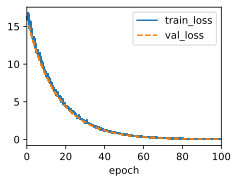

In [33]:
# test 
model = LinearRegressionScratch(2, lr=0.001)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=100)
trainer.fit(model, data)

In [34]:
# compare the prediction and the real params 
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.0818, -0.1472])
error in estimating b: tensor([0.1508])
